# Phase 0 — Manual Conflict Probe: Do Commercially Released Instruct Models Exhibit Context-Parametric Inversion?

**Hypothesis:** Commercially released instruct models sit in a *post-inversion* state they have been fully instruction-tuned past the context-reliance peak. On items where they demonstrably hold the parametric answer (no-context probe passes), they should preferentially output the **parametric** answer even when a well-written counterfactual context asserts otherwise. This is the inversion signature. We verify this manually across 20 stratified samples before building any automated pipeline.

**Models under test:**
- `meta-llama/Llama-3.1-8B-Instruct`
- `mistralai/Mistral-7B-Instruct-v0.1`
- `Qwen/Qwen2-7B-Instruct`

**Reference:** Context-Parametric Inversion with Instruction Finetuning (ICLR 2025), locuslab.

### All Imports

In [2]:
from google.colab import drive, userdata
drive.mount('/content/drive')

import subprocess, sys
def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

pip_install("transformers")
pip_install("accelerate")
pip_install("openai")

from huggingface_hub import login
login(token=userdata.get("colab_token"))
print("HuggingFace login successful.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
HuggingFace login successful.


### Import `eval.py` from Drive

`eval.py` is already uploaded to Drive we import it as a module rather than
copy-pasting any of its functions.

In [6]:
import sys, os, json
from datetime import datetime, timezone
from pathlib import Path

EVAL_PY_DIR = "/content/drive/MyDrive/context-parametric-inversion-research/evaluation"
sys.path.insert(0, EVAL_PY_DIR)

import eval as cpi  # eval.py, imported as a module — nothing reimplemented below

print("eval.py version:", cpi.__version__)

eval.py version: 1.0.0


### Experiment configuration

Three released checkpoints, dataset path, and output directory matching the required layout:

```
phase0_Results/
    model_1/results.json
    model_2/results.json
    model_3/results.json
```

In [17]:
MODELS = [
    {"id": "allenai/OLMo-2-1124-7B",   "use_chat_template": False},

]

CONFLICT_JSON = "/content/drive/MyDrive/context-parametric-inversion-research/dataset/conflict_eval_unified.json"
OUT_DIR       = "/content/drive/MyDrive/context-parametric-inversion-research/OLMO-2"
os.makedirs(OUT_DIR, exist_ok=True)

TAU           = cpi.TAU
K_DISTRACTORS = cpi.K_DISTRACTORS
DROP_IDS      = cpi.DEFAULT_DROP_IDS   # NOTE: confirm against evaluation_pipeline.md Sec.2.3
                                        # (docstring says 9 flagged items, only 5 IDs listed —
                                        # flagged in Phase 1 review, not yet resolved)

### Layer-2 judge — mandatory for this run

Constructed once, reused across all three models (shares nothing stateful across models
except the response cache, which is keyed by `(item_id, checkpoint_id, response_hash)` so
that's safe).

In [18]:
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
judge_fn = cpi.make_judge()
print("Judge ready:", cpi.JUDGE_MODEL)

Judge ready: gpt-4.1-nano


### Load dataset + build the Layer-0 distractor pool

`load_items` drops the flagged items; `build_distractor_pool` groups remaining items
by `source` for the genuine-conflict filter. Both are `eval.py` functions, called as-is.

In [19]:
items = cpi.load_items(CONFLICT_JSON, drop_ids=DROP_IDS)
id_map = {it["item_id"]: it for it in items}
pool = cpi.build_distractor_pool(items)

print("strata:", {s: sum(i["source"] == s for i in items) for s in sorted({i["source"] for i in items})})

Loaded 417 total | dropped 5 flagged item(s) | 412 usable
strata: {'country_capitals': 191, 'famous_biographies': 106, 'world_facts': 115}


## Experiment 1 — Full four-layer evaluation, per checkpoint

For each model:
1. Load fresh (bf16).
2. Run `evaluate()` — Layer 0 (filter) → Layer 1 (log-prob) → Layer 2 (judge, mandatory here)
   → Layer 3 (diagnostics), with `record_gen_filter=True` so the no-context filter boolean
   is recorded too.
3. Separately capture the actual **no-context generation text** per item, using `eval.py`'s
   own `build_gen_prompt_ids` / `generate` (this text isn't stored by `evaluate()` itself —
   only a derived boolean is — so we attach it here without touching the library).
4. Free the model, assemble the required record, write `phase0_Results/model_i/results.json`.

In [20]:
def run_one_model(model_cfg, model_index):
    model_id = model_cfg["id"]
    use_ct   = model_cfg["use_chat_template"]
    safe_name = model_id.split("/")[-1]

    print(f"\n{'='*70}\n  MODEL {model_index}: {model_id}\n{'='*70}")
    model, tok = cpi.load_model(model_id, precision="bf16")

    result = cpi.evaluate(
        model, tok, items, use_ct, pool,
        methods=("paper", "ordered", "logprob"),
        record_gen_filter=True,
        tau=TAU,
        judge_fn_=judge_fn,                       # mandatory judge
        checkpoint_id=f"phase0_{safe_name}",
        k_distractors=K_DISTRACTORS,
        verbose=True,
    )

    # Attach the actual no-context generation text (not stored by evaluate() itself)
    for rec in result["per_item"]:
        it = id_map[rec["item_id"]]
        no_ctx_ids = cpi.build_gen_prompt_ids(tok, it["question"], None, use_ct)
        rec["response_no_context"] = cpi.generate(model, tok, no_ctx_ids)

    cpi.free_model(model)

    # --- Safety check: judge is mandatory, so no item should be left as "AMBIG" ---
    unresolved = [r["item_id"] for r in result["per_item"] if r.get("final_label") == "AMBIG"]
    assert not unresolved, (
        f"{model_id}: {len(unresolved)} item(s) left with final_label='AMBIG' "
        f"despite judge_fn_ being set — investigate judge failures: {unresolved[:5]}"
    )

    out = {
        "model_id": model_id,
        "model_index": model_index,
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "config": {
            "tau": TAU, "k_distractors": K_DISTRACTORS,
            "use_chat_template": use_ct, "precision": "bf16",
            "n_items_total": len(items), "judge_enabled": True,
            "judge_model": cpi.JUDGE_MODEL, "eval_py_version": cpi.__version__,
        },
        "aggregate": result["summary"]["aggregate"],
        "per_stratum": result["summary"]["per_stratum"],
        "filter_yield": result["summary"]["filter_yield"],
        "per_item": result["per_item"],
    }

    model_dir = Path(OUT_DIR) / f"model_{model_index}"
    model_dir.mkdir(parents=True, exist_ok=True)
    out_file = model_dir / "results.json"
    with open(out_file, "w") as f:
        json.dump(out, f, indent=2)

    cpi.print_summary(model_id, result)
    print(f"Wrote {out_file}")
    return out

phase0_results = {}
for i, cfg in enumerate(MODELS, start=1):
    phase0_results[f"model_{i}"] = run_one_model(cfg, i)


  MODEL 1: allenai/OLMo-2-1124-7B
Loading allenai/OLMo-2-1124-7B  precision=bf16


config.json:   0%|          | 0.00/623 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.34k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.61M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/917k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/29.6k [00:00<?, ?B/s]

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/355 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

  Memory footprint: 14.60 GB (precision=bf16)
GPU memory released.

### allenai/OLMo-2-1124-7B  | filter_yield=0.964
  FINAL   R_ctx=0.751  R_par=0.242  R_other=0.008
  PAPER   R_ctx=0.783  R_par=0.244  (not a partition)
  ORDERED R_ctx=0.776  R_par=0.207  R_other=0.018
  LOGPROB R_ctx=0.448  R_par=0.055  R_ambiguous=0.496
  escalation_rate=0.496  layer2_failed_rate=0.0  other_breakdown={'hallucinated': 0.008}
    [country_capitals     n=186] final R_ctx=0.726  filter_yield=0.974  escalation=0.694
    [famous_biographies   n=103] final R_ctx=0.835  filter_yield=0.972  escalation=0.223
    [world_facts          n=108] final R_ctx=0.713  filter_yield=0.939  escalation=0.417
Wrote /content/drive/MyDrive/context-parametric-inversion-research/OLMO-2/model_1/results.json


### Cross-model comparison

Quick headline table — `R_ctx` under `final` (the judge-backstopped rate) per model,
plus filter yield and escalation rate, so you can sanity-check before digging into per-item data.

In [21]:
print(f"{'model':<32} {'R_ctx':>7} {'R_par':>7} {'R_other':>8} {'filter_yield':>13} {'escalation':>11}")
print("-" * 82)
for i, cfg in enumerate(MODELS, start=1):
    r = phase0_results[f"model_{i}"]
    agg = r["aggregate"]["final"]
    print(f"{cfg['id']:<32} {agg['R_ctx']['mean']:>7} {agg['R_par']['mean']:>7} "
          f"{agg['R_other']['mean']:>8} {r['filter_yield']:>13} "
          f"{r['aggregate'].get('escalation_rate'):>11}")

model                              R_ctx   R_par  R_other  filter_yield  escalation
----------------------------------------------------------------------------------
allenai/OLMo-2-1124-7B             0.751   0.242    0.008         0.964       0.496


## Experiment 2 — Attention-pattern sanity check

A brief mechanistic peek, same spirit as the manual-probe notebook: is any attention-to-context
signal visible at all in a released instruct model? We use `Llama-3.1-8B-Instruct` (native
TransformerLens support) and pull real items **from this run's own results** rather than
hand-picking — one item Llama scored `PAR` on, one `CTX`, one `OTHER` (if available), all
drawn from items that passed the Layer-0 filter.

This is a diagnostic, not Arm-B analysis (which needs SFT trajectory checkpoints) — it's a
check for whether raw attention is where context influence lives, or whether (as prior work
suggests) it's carried in the residual stream instead.

In [16]:
pip_install("transformer_lens")
pip_install("einops")
pip_install("fancy_einsum")

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

llama_result = phase0_results["model_1"]  # Llama-3.1-8B-Instruct
passed_items = [r for r in llama_result["per_item"] if r["passed"]]

def pick_one(label):
    for r in passed_items:
        if r["final_label"] == label:
            return r
    return None

ATTN_RECORDS = [r for r in (pick_one("PAR"), pick_one("CTX"), pick_one("OTHER")) if r is not None]
print("Selected for attention analysis:")
for r in ATTN_RECORDS:
    print(f"  {r['item_id']}  final_label={r['final_label']}  "
          f"par={r['parametric_answer']!r}  cf={r['counterfactual_answer']!r}")

TL_MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"
tl_model = HookedTransformer.from_pretrained(
    TL_MODEL_ID, dtype="bfloat16", fold_ln=False,
    center_writing_weights=False, center_unembed=False,
)
tl_model.eval()
print("Loaded into TransformerLens.")

Selected for attention analysis:
  cap_0001  final_label=PAR  par='Tirana'  cf='Durrës'
  cap_0000  final_label=CTX  par='Kabul'  cf='Herat'
  cap_0028  final_label=OTHER  par='Phnom Penh'  cf='Siem Reap'


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.1-8B-Instruct into HookedTransformer
Loaded into TransformerLens.


In [ ]:
def build_no_context_prompt(question):
    return (f"Answer the following question in as few words as possible. "
            f"Do not explain. Do not add notes.\n\nQuestion: {question}\nAnswer:")

def build_with_context_prompt(context, question):
    return (f"Read the context and answer the question in as few words as possible. "
            f"Do not explain. Do not add notes.\n\nContext: {context}\n\nQuestion: {question}\nAnswer:")

def get_attention_to_spans(item, use_context, tl_model):
    prompt = (build_with_context_prompt(item["context"], item["question"])
              if use_context else build_no_context_prompt(item["question"]))
    tokens = tl_model.to_tokens(prompt)
    token_strs = tl_model.to_str_tokens(prompt)

    with torch.no_grad():
        _, cache = tl_model.run_with_cache(tokens, names_filter=lambda n: n.endswith("pattern"))

    n_layers, n_heads = tl_model.cfg.n_layers, tl_model.cfg.n_heads
    attn = torch.stack([cache[f"blocks.{l}.attn.hook_pattern"][0] for l in range(n_layers)]).float().cpu()
    T = tokens.shape[-1]

    ctx_start = ctx_end = q_start = q_end = None
    running = ""
    for i, t in enumerate(token_strs):
        running += t
        if use_context:
            if ctx_start is None and "Context:" in running:
                ctx_start = i
            if ctx_start is not None and ctx_end is None and "Question:" in running:
                ctx_end = i
        if q_start is None and "Question:" in running:
            q_start = i
    q_end = T - 1

    span_indices = {
        "bos_sink": [0],
        "context": list(range(ctx_start, ctx_end)) if (use_context and ctx_start and ctx_end) else [],
        "question": list(range(q_start, q_end)) if q_start else [],
        "other": [],
    }
    used = set(span_indices["bos_sink"]) | set(span_indices["context"]) | set(span_indices["question"])
    span_indices["other"] = [i for i in range(T) if i not in used]

    return {"attn": attn, "tokens": token_strs, "span_indices": span_indices, "T": T}

def aggregate_attn_to_spans(result):
    attn, span_indices, T = result["attn"], result["span_indices"], result["T"]
    last_tok = T - 1
    agg = {}
    for name, idxs in span_indices.items():
        agg[name] = (attn[:, :, last_tok, idxs].numpy().mean(axis=-1) if idxs
                     else np.zeros((attn.shape[0], attn.shape[1])))
    return agg

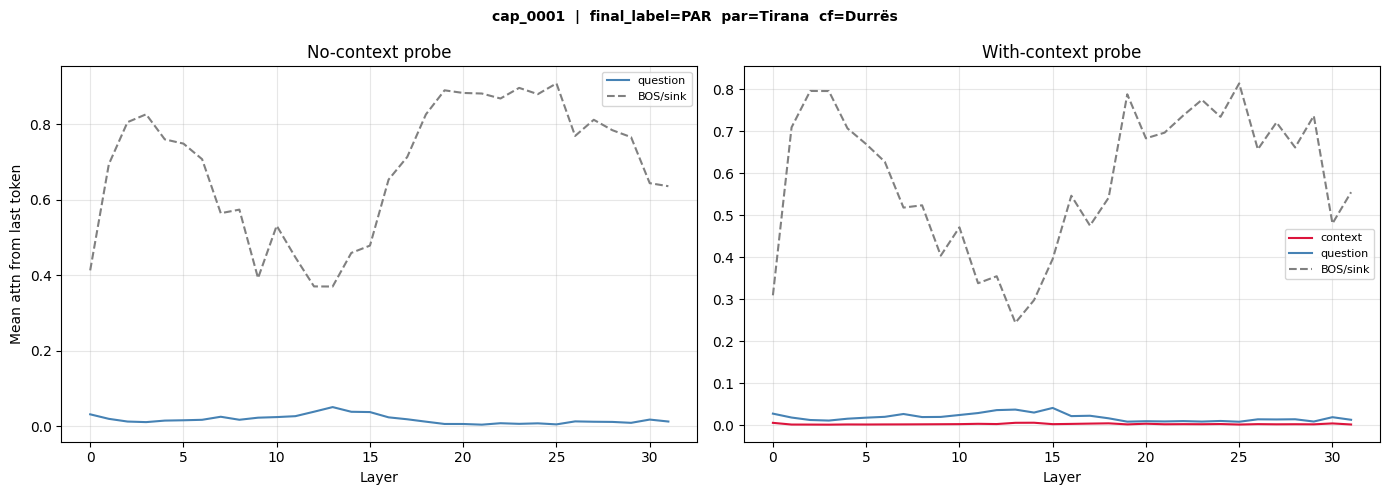

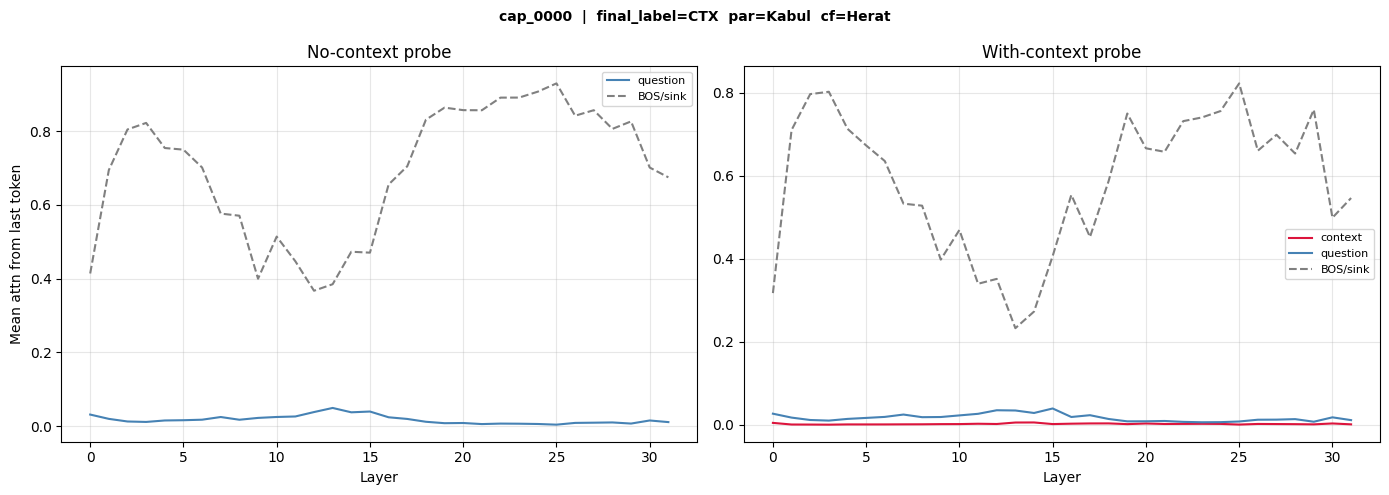

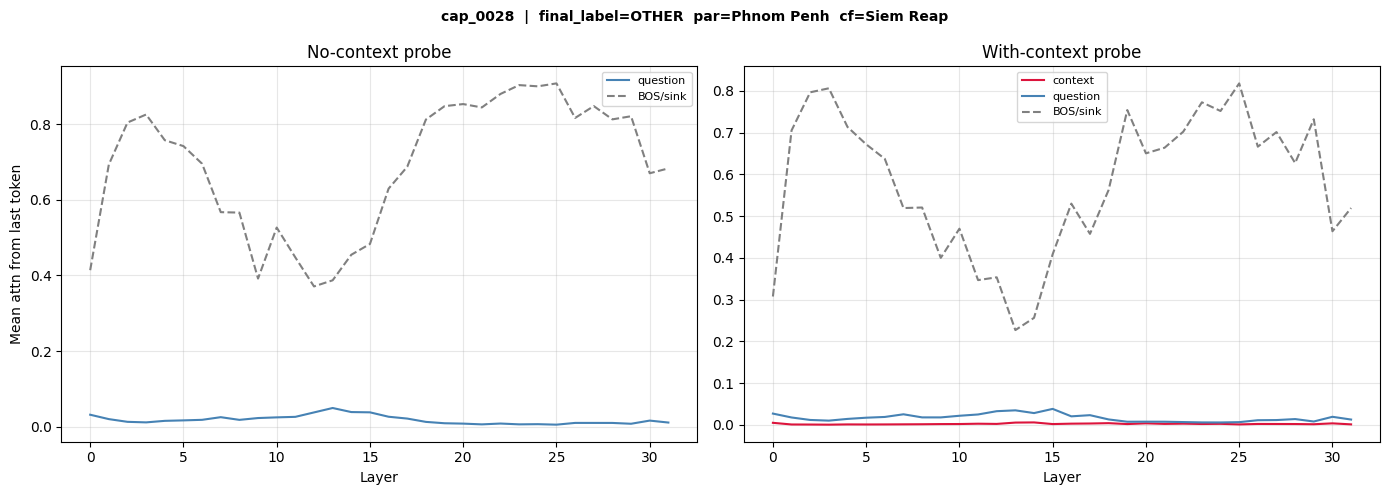

In [ ]:
def plot_attention_comparison(item, tl_model, figsize=(14, 5)):
    res_nc = get_attention_to_spans(item, use_context=False, tl_model=tl_model)
    res_wc = get_attention_to_spans(item, use_context=True, tl_model=tl_model)
    agg_nc, agg_wc = aggregate_attn_to_spans(res_nc), aggregate_attn_to_spans(res_wc)

    n_layers = tl_model.cfg.n_layers
    layers = np.arange(n_layers)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(f"{item['item_id']}  |  final_label={item['final_label']}  "
                 f"par={item['parametric_answer']}  cf={item['counterfactual_answer']}",
                 fontsize=10, fontweight="bold")

    ax = axes[0]
    ax.set_title("No-context probe")
    ax.plot(layers, agg_nc["question"].mean(axis=1), label="question", color="steelblue")
    ax.plot(layers, agg_nc["bos_sink"].mean(axis=1), label="BOS/sink", color="gray", linestyle="--")
    ax.set_xlabel("Layer"); ax.set_ylabel("Mean attn from last token"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = axes[1]
    ax.set_title("With-context probe")
    ax.plot(layers, agg_wc["context"].mean(axis=1), label="context", color="crimson")
    ax.plot(layers, agg_wc["question"].mean(axis=1), label="question", color="steelblue")
    ax.plot(layers, agg_wc["bos_sink"].mean(axis=1), label="BOS/sink", color="gray", linestyle="--")
    ax.set_xlabel("Layer"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

for r in ATTN_RECORDS:
    plot_attention_comparison(r, tl_model)

## Cross-Model Analysis & Supporting Report

Loads all three `phase0_Results/model_i/results.json` files, builds comparison tables/charts,
runs pairwise agreement checks (reusing `eval.py`'s own `mcnemar_test` — same function used
for SFT-checkpoint comparison, repurposed here for model-vs-model since it only needs paired
`final_label` flags keyed by `item_id`), and writes a markdown report to Drive.

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RESULTS_DIR = Path("/content/drive/MyDrive/context-parametric-inversion-research/phase0_Results")
REPORT_DIR  = RESULTS_DIR / "report"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

all_results = {}
for model_dir in sorted(RESULTS_DIR.glob("model_*")):
    if not model_dir.is_dir():
        continue
    with open(model_dir / "results.json") as f:
        r = json.load(f)
    all_results[model_dir.name] = r

print(f"Loaded {len(all_results)} result sets:")
for k, v in all_results.items():
    print(f"  {k}: {v['model_id']}  (n_items={v['config']['n_items_total']})")

Loaded 3 result sets:
  model_1: meta-llama/Llama-3.1-8B-Instruct  (n_items=416)
  model_2: mistralai/Mistral-7B-Instruct-v0.1  (n_items=416)
  model_3: Qwen/Qwen2-7B-Instruct  (n_items=416)


In [ ]:
for name, r in all_results.items():
    unresolved = [it["item_id"] for it in r["per_item"] if it.get("final_label") == "AMBIG"]
    assert not unresolved, f"{name}: {len(unresolved)} unresolved AMBIG final_label(s) found"
print("All models: final_label fully resolved to CTX/PAR/OTHER (partition holds).")

All models: final_label fully resolved to CTX/PAR/OTHER (partition holds).


In [ ]:
rows = []
for name, r in all_results.items():
    agg = r["aggregate"]
    rows.append({
        "model": r["model_id"],
        "n_items": r["config"]["n_items_total"],
        "filter_yield": r["filter_yield"],
        "R_ctx": agg["final"]["R_ctx"]["mean"],
        "R_ctx_ci": agg["final"]["R_ctx"]["ci"],
        "R_par": agg["final"]["R_par"]["mean"],
        "R_other": agg["final"]["R_other"]["mean"],
        "escalation_rate": agg.get("escalation_rate"),
        "layer2_failed_rate": agg.get("layer2_failed_rate"),
    })
summary_df = pd.DataFrame(rows).sort_values("R_ctx", ascending=False).reset_index(drop=True)
summary_df

,model,n_items,filter_yield,R_ctx,R_ctx_ci,R_par,R_other,escalation_rate,layer2_failed_rate
0,mistralai/Mistral-7B-Instruct-v0.1,416,0.978,0.897,"[0.867, 0.924]",0.096,0.007,0.270,0.0
1,meta-llama/Llama-3.1-8B-Instruct,416,0.990,0.689,"[0.643, 0.733]",0.299,0.012,0.427,0.0
2,Qwen/Qwen2-7B-Instruct,416,0.981,0.576,"[0.527, 0.623]",0.422,0.002,0.194,0.0


### Chart 1 — R_ctx / R_par / R_other per model (final, judge-backstopped)

Error bars are the bootstrap 95% CI already computed by `eval.py`'s `rate_ci` — not recomputed here.

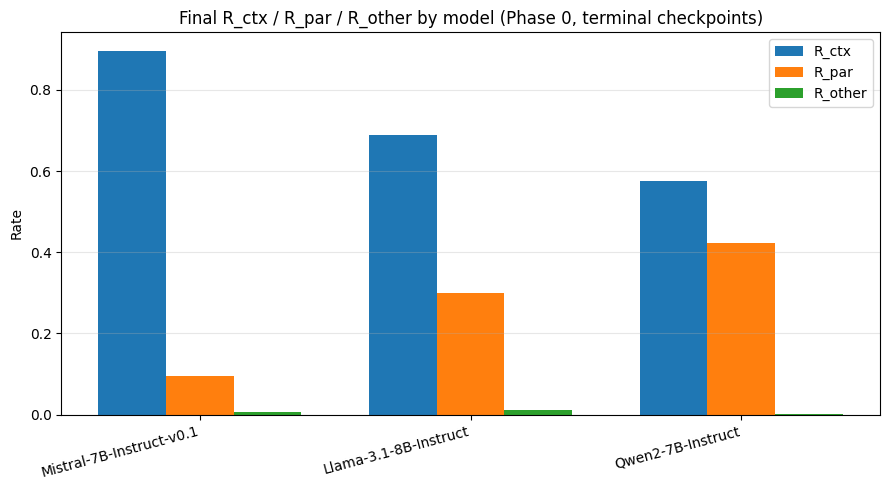

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(summary_df))
width = 0.25

for i, metric in enumerate(["R_ctx", "R_par", "R_other"]):
    means = summary_df[metric].values
    ax.bar(x + (i - 1) * width, means, width, label=metric)

ax.set_xticks(x)
ax.set_xticklabels([m.split("/")[-1] for m in summary_df["model"]], rotation=15, ha="right")
ax.set_ylabel("Rate")
ax.set_title("Final R_ctx / R_par / R_other by model (Phase 0, terminal checkpoints)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_DIR / "chart1_headline_rates.png", dpi=150)
plt.show()

### Chart 2 — Per-stratum R_ctx by model

Splits the headline number by `country_capitals` / `world_facts` / `famous_biographies` —
important since Phase 1 review flagged that stratum behavior is not uniform.

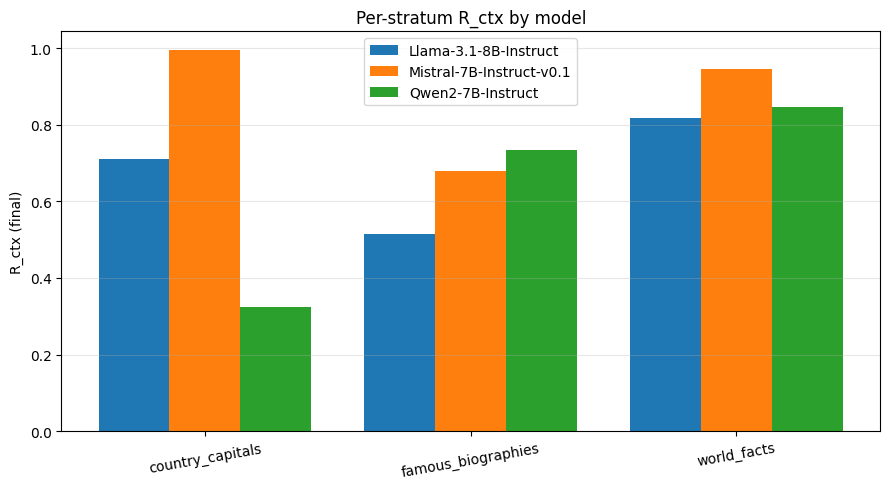

In [ ]:
strata = sorted({s for r in all_results.values() for s in r["per_stratum"]})
model_names = [r["model_id"].split("/")[-1] for r in all_results.values()]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(strata))
width = 0.8 / len(all_results)

for i, (name, r) in enumerate(all_results.items()):
    vals = [r["per_stratum"][s].get("final", {}).get("R_ctx", {}).get("mean") for s in strata]
    ax.bar(x + i * width, vals, width, label=r["model_id"].split("/")[-1])

ax.set_xticks(x + width * (len(all_results) - 1) / 2)
ax.set_xticklabels(strata, rotation=10)
ax.set_ylabel("R_ctx (final)")
ax.set_title("Per-stratum R_ctx by model")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_DIR / "chart2_per_stratum.png", dpi=150)
plt.show()

### Chart 3 — Escalation rate & OTHER breakdown per model

How much of each model's evaluation relied on the Layer-2 judge, and what the OTHER
verdicts actually consisted of (hedged / abstained / hallucinated / judge failures).

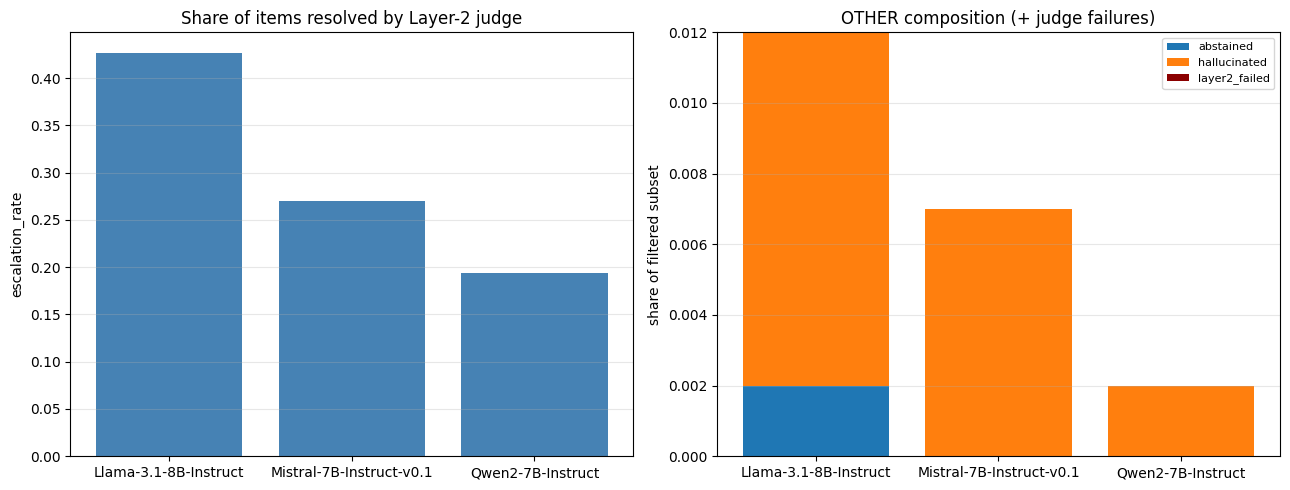

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

esc = [r["aggregate"].get("escalation_rate", 0) for r in all_results.values()]
axes[0].bar(model_names, esc, color="steelblue")
axes[0].set_ylabel("escalation_rate")
axes[0].set_title("Share of items resolved by Layer-2 judge")
axes[0].grid(axis="y", alpha=0.3)

other_types = sorted({k for r in all_results.values()
                       for k in r["aggregate"].get("other_breakdown", {})})
bottom = np.zeros(len(all_results))
for ot in other_types:
    vals = np.array([r["aggregate"].get("other_breakdown", {}).get(ot, 0) for r in all_results.values()])
    axes[1].bar(model_names, vals, bottom=bottom, label=ot)
    bottom += vals
fail_vals = np.array([r["aggregate"].get("layer2_failed_rate", 0) for r in all_results.values()])
axes[1].bar(model_names, fail_vals, bottom=bottom, label="layer2_failed", color="darkred")
axes[1].set_ylabel("share of filtered subset")
axes[1].set_title("OTHER composition (+ judge failures)")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(REPORT_DIR / "chart3_escalation_other.png", dpi=150)
plt.show()

### Chart 4 — Δ (logit gap) distributions

Histogram of Layer 1's continuous `delta` per model, with the ±τ gate marked. Shows how much
mass sits in the AMBIG band versus how decisively confident items are — a single-number
escalation_rate hides this shape.

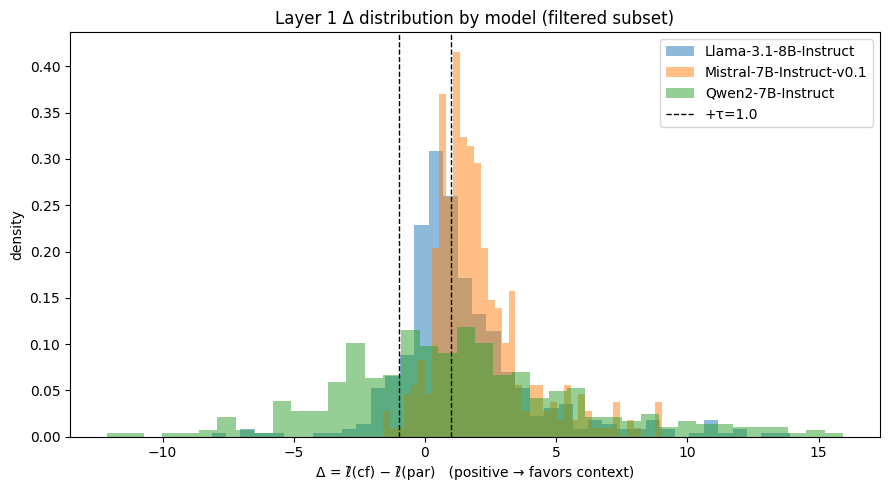

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
tau = all_results[list(all_results)[0]]["config"]["tau"]

for name, r in all_results.items():
    deltas = [it["logprob"]["delta"] for it in r["per_item"]
              if it["passed"] and "delta" in it.get("logprob", {})]
    ax.hist(deltas, bins=40, alpha=0.5, label=r["model_id"].split("/")[-1], density=True)

ax.axvline(tau, color="black", linestyle="--", linewidth=1, label=f"+τ={tau}")
ax.axvline(-tau, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Δ = ℓ̄(cf) − ℓ̄(par)   (positive → favors context)")
ax.set_ylabel("density")
ax.set_title("Layer 1 Δ distribution by model (filtered subset)")
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "chart4_delta_distribution.png", dpi=150)
plt.show()

### Method agreement — Layer 3 diagnostics vs. `final`

Cross-check per model: does `paper`/`ordered` roughly track `final`, per the design intent
that they're independent validity checks, not inputs? Reported as agreement rate, not a
formal metric, since `paper`'s cf_acc/par_acc are explicitly not a partition.

In [ ]:
agree_rows = []
for name, r in all_results.items():
    items = [it for it in r["per_item"] if it["passed"]]
    ordered_agree = np.mean([it["ordered"]["label"] == it["final_label"] for it in items])
    paper_cf_agree_with_ctx = np.mean([
        (it["paper"]["cf_acc"] == 1) == (it["final_label"] == "CTX") for it in items
    ])
    agree_rows.append({
        "model": r["model_id"].split("/")[-1],
        "ordered_vs_final_agreement": round(ordered_agree, 3),
        "paper_cf_acc_vs_final_CTX_agreement": round(paper_cf_agree_with_ctx, 3),
    })
pd.DataFrame(agree_rows)

,model,ordered_vs_final_agreement,paper_cf_acc_vs_final_CTX_agreement
0,Llama-3.1-8B-Instruct,0.932,0.937
1,Mistral-7B-Instruct-v0.1,0.946,0.951
2,Qwen2-7B-Instruct,0.931,0.926


### Pairwise model comparison — McNemar's test

Reusing `eval.py`'s `paired_ctx_flags_from_checkpoints` / `mcnemar_test` as-is — they only
need two lists of per-item records with `passed` and `final_label`, keyed by `item_id`. That's
exactly what we have for two *models* here, not just two checkpoints of one model, so no
reimplementation needed. Restricted to items that passed the Layer-0 filter in **both** models
being compared (the function already enforces this).

In [ ]:
from itertools import combinations

pairwise_rows = []
for (name_a, r_a), (name_b, r_b) in combinations(all_results.items(), 2):
    pairs, n_common = cpi.paired_ctx_flags_from_checkpoints(r_a["per_item"], r_b["per_item"])
    result = cpi.mcnemar_test(pairs)
    pairwise_rows.append({
        "model_a": r_a["model_id"].split("/")[-1],
        "model_b": r_b["model_id"].split("/")[-1],
        "n_common_items": n_common,
        "n01_switched_to_ctx_in_b": result["n01"],
        "n10_switched_from_ctx_in_b": result["n10"],
        "p_value": result["p_value"],
    })
pairwise_df = pd.DataFrame(pairwise_rows)
pairwise_df

,model_a,model_b,n_common_items,n01_switched_to_ctx_in_b,n10_switched_from_ctx_in_b,p_value
0,Llama-3.1-8B-Instruct,Mistral-7B-Instruct-v0.1,406,100,15,0.0000
1,Llama-3.1-8B-Instruct,Qwen2-7B-Instruct,406,56,100,0.0005
2,Mistral-7B-Instruct-v0.1,Qwen2-7B-Instruct,402,17,146,0.0000


In [ ]:
report_lines = []
report_lines.append("# Phase 0 — Baseline CPI Evaluation Report\n")
report_lines.append(f"_Generated: {pd.Timestamp.now(tz='UTC').isoformat()}_\n")

report_lines.append("## 1. Models evaluated\n")
for name, r in all_results.items():
    report_lines.append(f"- **{r['model_id']}** — n_items={r['config']['n_items_total']}, "
                         f"τ={r['config']['tau']}, judge={'enabled' if r['config']['judge_enabled'] else 'disabled'}")

report_lines.append("\n## 2. Headline results (final, judge-backstopped)\n")
report_lines.append(summary_df.to_markdown(index=False))

report_lines.append("\n\n## 3. Per-stratum breakdown\n")
for name, r in all_results.items():
    report_lines.append(f"\n**{r['model_id']}**\n")
    strat_rows = []
    for s, b in r["per_stratum"].items():
        if "final" in b:
            strat_rows.append({
                "stratum": s, "n_passed": b["n_passed"],
                "R_ctx": b["final"]["R_ctx"]["mean"],
                "filter_yield": b.get("filter_yield"),
                "escalation_rate": b.get("escalation_rate"),
            })
    report_lines.append(pd.DataFrame(strat_rows).to_markdown(index=False))

report_lines.append("\n\n## 4. Method agreement diagnostics\n")
report_lines.append(pd.DataFrame(agree_rows).to_markdown(index=False))

report_lines.append("\n\n## 5. Pairwise model comparison (McNemar)\n")
report_lines.append(pairwise_df.to_markdown(index=False))

report_lines.append("\n\n## 6. Charts\n")
report_lines.append("![headline](chart1_headline_rates.png)\n")
report_lines.append("![per-stratum](chart2_per_stratum.png)\n")
report_lines.append("![escalation](chart3_escalation_other.png)\n")
report_lines.append("![delta-distribution](chart4_delta_distribution.png)\n")

report_lines.append("\n\n## 7. Notes / caveats\n")
report_lines.append(
    "- These are terminal-checkpoint (released, post-alignment) readings, not an SFT "
    "trajectory — high R_ctx here does not rule out CPI having occurred earlier in "
    "training and being reversed by later alignment stages; that requires Arm B "
    "(checkpoint trajectory) data.\n"
    "- `R_ctx`/`R_par`/`R_other` under `final` are guaranteed to partition to 1.0 here "
    "because the Layer-2 judge was mandatory for this run (see assertion above) — "
    "no `AMBIG` leaked into `final_label`.\n"
    "- `paper`/`ordered` are diagnostics only and were never used to compute `final`; "
    "their agreement with `final` above is a validity check on the measurement, not "
    "a second vote.\n"
)

report_text = "\n".join(report_lines)
report_path = REPORT_DIR / "phase0_report.md"
with open(report_path, "w") as f:
    f.write(report_text)

print(f"Report written to {report_path}")
print(f"\n{'='*60}\nPreview:\n{'='*60}")
print(report_text[:1500])

Report written to /content/drive/MyDrive/context-parametric-inversion-research/phase0_Results/report/phase0_report.md

Preview:
# Phase 0 — Baseline CPI Evaluation Report

_Generated: 2026-07-06T10:31:01.422262+00:00_

## 1. Models evaluated

- **meta-llama/Llama-3.1-8B-Instruct** — n_items=416, τ=1.0, judge=enabled
- **mistralai/Mistral-7B-Instruct-v0.1** — n_items=416, τ=1.0, judge=enabled
- **Qwen/Qwen2-7B-Instruct** — n_items=416, τ=1.0, judge=enabled

## 2. Headline results (final, judge-backstopped)

| model                              |   n_items |   filter_yield |   R_ctx | R_ctx_ci       |   R_par |   R_other |   escalation_rate |   layer2_failed_rate |
|:-----------------------------------|----------:|---------------:|--------:|:---------------|--------:|----------:|------------------:|---------------------:|
| mistralai/Mistral-7B-Instruct-v0.1 |       416 |          0.978 |   0.897 | [0.867, 0.924] |   0.096 |     0.007 |             0.27  |                    0 |
| meta-l

### Per-head attention heatmap

Same idea as the earlier manual-probe notebook: at a few representative layers, plot each
individual head's mean attention (from the final/prediction token) to context vs. question
vs. BOS-sink, for the with-context probe. This reveals whether specific heads specialize in
attending to context even if the layer-averaged view (previous chart) looks flat/sink-dominated.

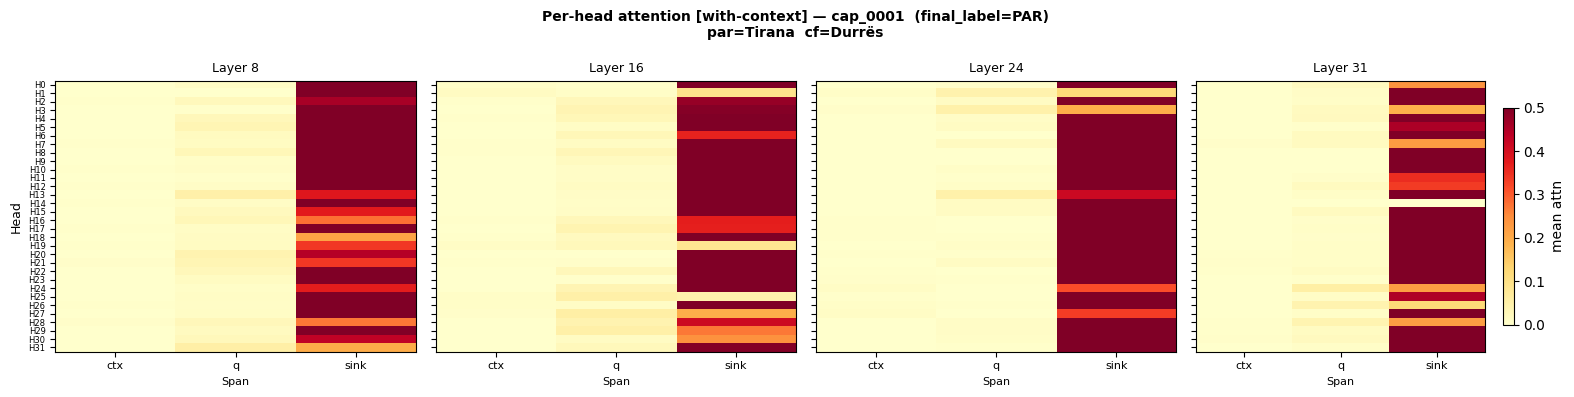

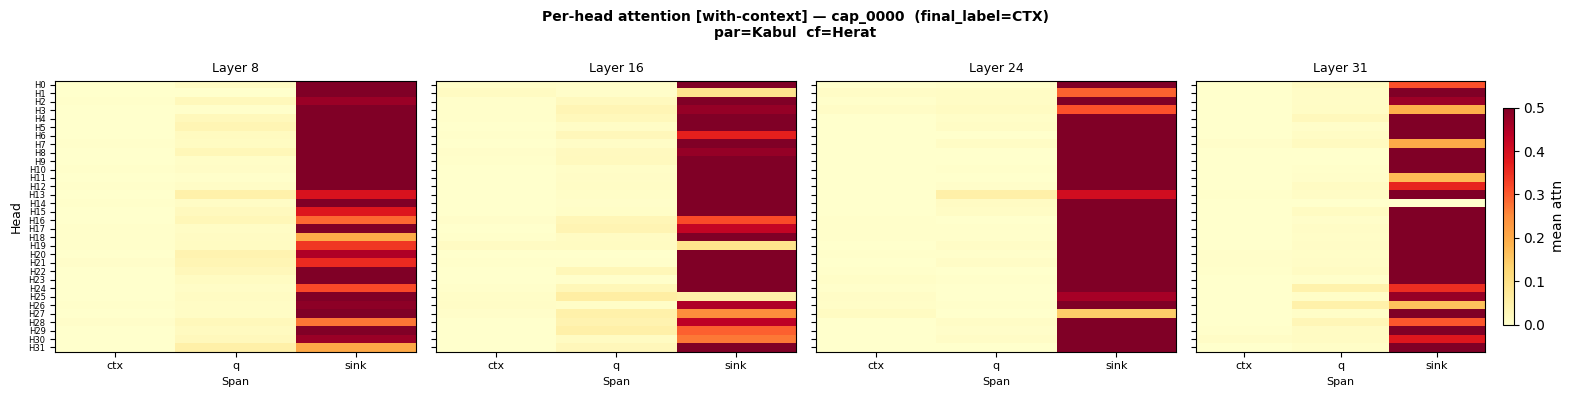

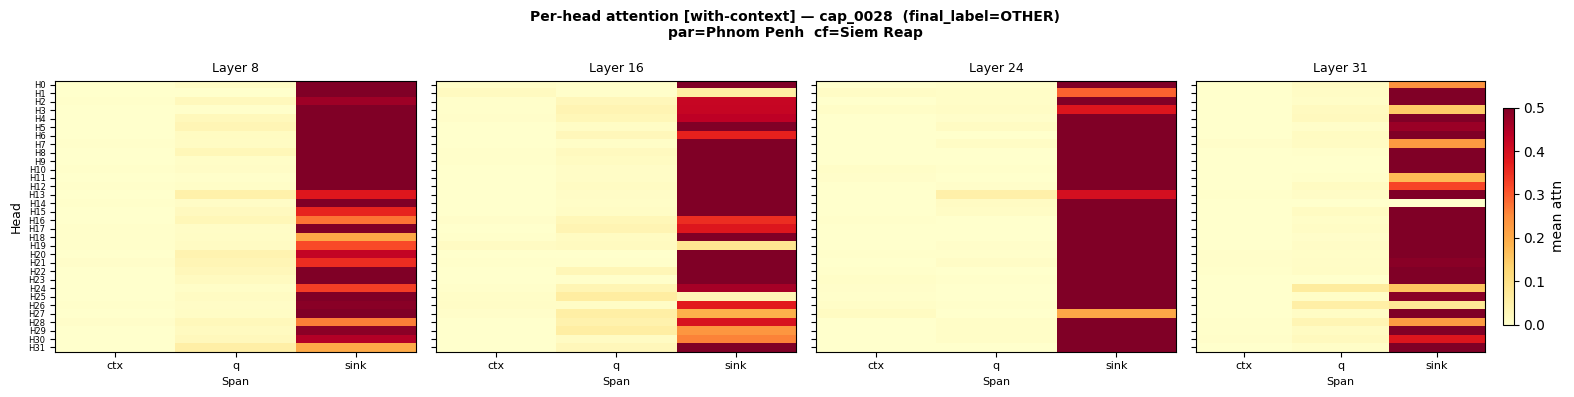

In [ ]:
def plot_head_heatmap(item, tl_model, layers_to_show=None):
    """
    For the with-context probe, plot a heatmap of (context attn, question attn, bos_sink attn)
    per head at selected layers. Reveals which specific heads drive context attention, even
    when the layer-averaged view looks sink-dominated.
    """
    if layers_to_show is None:
        n = tl_model.cfg.n_layers
        layers_to_show = sorted(set([n // 4, n // 2, 3 * n // 4, n - 1]))

    res_wc = get_attention_to_spans(item, use_context=True, tl_model=tl_model)
    agg_wc = aggregate_attn_to_spans(res_wc)

    n_heads = tl_model.cfg.n_heads
    fig, axes = plt.subplots(1, len(layers_to_show),
                              figsize=(4 * len(layers_to_show), 4), sharey=True)
    if len(layers_to_show) == 1:
        axes = [axes]

    fig.suptitle(
        f"Per-head attention [with-context] — {item['item_id']}  "
        f"(final_label={item['final_label']})\n"
        f"par={item['parametric_answer']}  cf={item['counterfactual_answer']}",
        fontsize=10, fontweight="bold"
    )

    im = None
    for ax, layer in zip(axes, layers_to_show):
        data = np.stack([
            agg_wc["context"][layer],   # context attn per head
            agg_wc["question"][layer],  # question attn per head
            agg_wc["bos_sink"][layer],  # sink attn per head
        ], axis=1)  # (n_heads, 3)

        im = ax.imshow(data, aspect="auto", cmap="YlOrRd", vmin=0, vmax=0.5)
        ax.set_title(f"Layer {layer}", fontsize=9)
        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(["ctx", "q", "sink"], fontsize=8)
        ax.set_yticks(range(n_heads))
        ax.set_yticklabels([f"H{h}" for h in range(n_heads)], fontsize=6)
        ax.set_xlabel("Span", fontsize=8)

    axes[0].set_ylabel("Head", fontsize=9)
    fig.colorbar(im, ax=axes[-1], shrink=0.8, label="mean attn")
    plt.tight_layout()

    safe_id = item["item_id"]
    plt.savefig(REPORT_DIR / f"chart5_head_heatmap_{safe_id}.png", dpi=150)
    plt.show()

for r in ATTN_RECORDS:
    plot_head_heatmap(r, tl_model)